In [1]:
"""
This notebook aims to produce the result of strict mean field theory by using qubits set to mean field solution.
"""

'\nThis notebook aims to produce the result of strict mean field theory by using qubits set to mean field solution.\n'

In [2]:
%load_ext autoreload
%autoreload 2
%autosave 0
%precision %g

import sys, os, glob, time
import re
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.lines as lines
import functools as ft
import numpy as np
import numpy.random as rnd
import scipy.integrate as integ
import qiskit as qk
import qiskit_aer as aer
import qiskit_algorithms as qalgo
import qiskit_ibm_runtime as qkrun
import qiskit_experiments as qkexp
import qiskit_braket_provider as braket

# Launch Wolfram language interface
# from wolframclient.evaluation import WolframLanguageSession
# from wolframclient.language import wl, wlexpr
# wl_session = WolframLanguageSession()

from tqdm import tqdm

import sys

sys.path.append("../")

# Directories
# if os.uname().sysname == 'Linux':
#     base_dir = os.path.expanduser("~/sn-quant/")
# else:
#     base_dir = os.path.expanduser("~/Dropbox/sn-quant/jk/")

#base_dir = os.path.join("../", "joachim")
#os.chdir(base_dir)

# set up matplotlib
%matplotlib inline
# matplotlib.rcParams['text.usetex']    = True
# matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amssymb}'
matplotlib.rcParams['font.family']    = 'serif'
matplotlib.rcParams['font.size']      = '16'
# matplotlib.rcParams['figure.figsize'] = 6.4, 4.8
matplotlib.rcParams['figure.figsize'] = 16, 8

# Unit conversion and physical constants
class my_units:
    # Energy and mass
    eV     = 1.
    keV    = 1.e3
    MeV    = 1.e6
    GeV    = 1.e9
    TeV    = 1.e12
    PeV    = 1.e15
    kg     = 5.62e35*eV
    grams  = 0.001*kg
    Kelvin = 8.617333262e-5       # PDG 2022
    Joule  = 1/1.602176634e-19*eV # PDG 2022 [exact]
    erg    = 1e-7*Joule
    
    # Length and time
    m     = 5.076e6
    meter = m
    km    = 1000*m
    cm    = 0.01*m
    nm    = 1.e-9*m
    fm    = 1.e-15*m
    AU    = 1.4960e11*m
    pc    = 30.857e15*m
    kpc   = 1.e3*pc
    Mpc   = 1.e6*pc
    Gpc   = 1.e9*pc
    ly    = 9460730472580800*m  # light year
    sec   = 1.523e15
    hours = 3600*sec
    days  = 24*hours
    yrs   = 365*days
    Hz    = 1./sec
    kHz   = 1.e3*Hz
    MHz   = 1.e6*Hz
    GHz   = 1.e9*Hz
    
    barn  = 1.e-24*cm**2
    pb    = 1.e-36*cm**2
    fb    = 1.e-39*cm**2
    
    # Various astrophysical constants
    GN    = 6.708e-39/1e18  # eV^-2, Newton's constant
    MPl   = 1.22093e19*GeV   # Planck mass, PDG 2013
    Msun  = 1.989e30*kg
    Rsun  = 6.9551e8*meter
    
    # cosmology
    h        = 0.674                         # according to Planck 2018
    H0       = h * 100. * km / sec/ Mpc      # Hubble parameter
    rho_c0   = 3. * H0**2/(8. * np.pi * GN)  # critical density today, Kolb Turner eq. (3.14)
    Omega_dm = 0.12 / h**2                   # dark matter density, Planck 2018
    
    # particle physics
    alpha_em = (1./137.035999139)            # electromagnetic fine structure constant (PDG 2018)
    GF       = 1.166378e-5 / GeV**2          # Fermi constant (PDG 2022)
    s2thW    = 1.03232 * 0.23121             # sin^2 \theta_W(M_Z) from PDG 2022; \kappa from https://arxiv.org/abs/1608.02671
    m_e      = 0.5109989461 * MeV            # electron mass (PDG 2018)
    m_mu     = 105.6583745 * MeV             # muon mass (PDG 2018)
    m_tau    = 1776.86 * MeV                 # tau mass (PDG 2018)
    m_p      = 938.2720813 * MeV             # proton mass (PDG 2018)
    m_n      = 939.565413 * MeV              # neutron mass (PDG 2018)
    m_u      = 931.4940954 * MeV             # atomic mass unit (PDG 2018)
    m_pi0    = 134.9768 * MeV                # neutral pion mass (PDG 2020)
    tau_mu   = 2.1969811e-6 * sec            # muon lifetime (PDG 2018)
    gA       = 1.26                          # axial coupling constant of the proton
    
    # PDG codes
    pdg_nu_e      = 12
    pdg_nu_mu     = 14
    pdg_nu_tau    = 16
    pdg_e         = 11
    pdg_mu        = 13
    pdg_tau       = 15
    pdg_gamma     = 22
    pdg_pip       = 211
    pdg_pi0       = 111
    pdg_KL        = 130
    pdg_Kp        = 321
    pdg_Dp        = 411
    pdg_D0        = 421
    pdg_Dp2s_2460 = 415
    pdg_D02s_2460 = 425
    pdg_Dsp       = 431
    pdg_Dsps      = 433
    pdg_Ds2s_2573 = 435
    
u = my_units()

# Pauli matrices
sigma_0 = np.array([[1, 0],  [0,  1]])
sigma_1 = np.array([[0, 1],  [1,  0]])
sigma_2 = np.array([[0,-1j], [1j, 0]])
sigma_3 = np.array([[1, 0],  [0, -1]])


Autosave disabled


In [3]:
import sys

sys.path.append("../")

from utils.Collector import Collector

cl = Collector()

In [ ]:
"""
Functions taken from bipolar-oscillations.ipynb, Raffelt–Sigl Polarization-Vector Approach to Collective Oscillations
"""

def P_osc_RS(t_table, theta, omega, lam, J, initial_flavors=None, alpha=None):
    """Compute an oscillation probability for collective oscillations
       in the Raffelt-Sigl 2-flavor polarization vector approach.
       
       Arguments:
           t_table: list of time steps
           theta:   vacuum mixing angle
           omega:   vector of vacuum oscillation frequencies for each mode
           lam:     strength of ordinary matter effect
           J:       matrix of coupling strengths between modes
           initial_flavors: an array of length n_modes indicating the initial flavor of
                    each neutrino ('e', 'x', or 'a'). If any neutrino has flavor 'a',
                    an angle alpha must be specified.
           alpha:   initial superposition for neutrinos in flavor 'a'
    """
    
    n_modes = J.shape[0]
    
    # definition of the vectors B, D, L, P, H, e3m in the notation of
    # https://arxiv.org/abs/1001.2799 (Duan, Fuller Qian)
    u   = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    b   = 0.5 * np.diag([-1,1])
    b   = u @ b @ u.T
    l   = np.diag([1,0])
    
    Ee  = np.array([0, 0,  1.])
    Emu = np.array([0, 0, -1.])
    B   = np.real(np.array([np.trace(b@sigma_1), np.trace(b@sigma_2), np.trace(b@sigma_3)]))
    L   = np.real(np.array([np.trace(l@sigma_1), np.trace(l@sigma_2), np.trace(l@sigma_3)]))
    
    ini_state = np.where(omega>0, Ee[:,None], Emu[:,None])
    if initial_flavors is not None:
        for f in initial_flavors:
            if f not in ['e','x','mu','a']:
                raise ValueError(f'Unknown flavor: {f}')
            if f == 'a' and alpha is None:
                raise ValueError('Initial superposition for neutrinos in flavor "a" not specified')
        ini_state[:,initial_flavors=='e']  = Ee[:,None]
        ini_state[:,initial_flavors=='x']  = Emu[:,None]
        ini_state[:,initial_flavors=='mu'] = Emu[:,None]
        ini_state[:,initial_flavors=='a']  = np.array([np.sin(2*alpha), 0, np.cos(2*alpha)])[:,None]
        # FIXME I'm not sure this is correct
        
    def f(t, P):
        """right-hand side of the evolution equation for the polarization vector P at time t."""
        
        res = np.zeros(3*n_modes)
        PP  = np.reshape(P, (n_modes,3)).T
        for k in range(n_modes):
            res[3*k:3*k+3] = np.cross(omega[k]*B + lam*L + PP@J[k,:], PP[:,k])
        return res

    return integ.solve_ivp(f, (t_table[0],t_table[-1]), ini_state.T.flatten(), t_eval=t_table)

def P_osc_RS_bipolar(t_table, theta, omega, lam, J, eps=0.1):
    """Compute an oscillation probability for collective oscillations
       in the Raffelt-Sigl 2-flavor polarization vector approach for
       a bipolar system.
       
       Arguments:
           t_table: list of time steps
           theta:   vacuum mixing angle
           omega:   vector of vacuum oscillation frequencies for each mode
           lam:     strength of ordinary matter effect
           J:       matrix of coupling strengths between modes
           eps:     asymmetry between neutrinos and anti-neutrinos"""
    
    n_modes = J.shape[0]
    
    # definition of the vectors B, D, L, P, H, e3m in the notation of
    # https://arxiv.org/abs/1001.2799 (Duan, Fuller, Qian)
    u   = np.array([[np.cos(theta), np.sin(theta)], [-np.sin(theta), np.cos(theta)]])
    b   = 0.5 * np.diag([-1,1])
    b   = u @ b @ u.T
    l   = np.diag([1,0])
    
    Ee  = np.array([0, 0,  1+eps])
    Emu = np.array([0, 0, -1+eps])
    B   = np.array([np.trace(b@sigma_1), np.trace(b@sigma_2), np.trace(b@sigma_3)])
    L   = np.array([np.trace(l@sigma_1), np.trace(l@sigma_2), np.trace(l@sigma_3)])
    
    def f(t, P):
        """right-hand side of the evolution equation for the polarization vector P at time t."""
        
        res = (0+0j)*np.zeros(3*n_modes)
        PP  = np.reshape(P, (n_modes,3)).T
        for k in range(n_modes):
            s  = 1 if k < n_modes//2 else -1
            res[3*k:3*k+3] = np.cross(s*omega[k]*B + lam*L + PP@J[k,:], PP[:,k])
        return res
            
    E0 = np.concatenate((np.tile(Ee,n_modes//2), np.tile(Emu,n_modes//2)))
    return integ.solve_ivp(f, (t_table[0],t_table[-1]), E0, t_eval=t_table)    

def U_self_int(theta):
   """the exponential of the neutrino interaction Hamiltonian,
      see Friedland & Lunardini, https://arxiv.org/abs/hep-ph/0304055
   """
   return np.array([[np.exp(-1j*theta), 0,                          0,                          0],
                  [0,                 0.5*( 1+np.exp(-1j*theta)), 0.5*(-1+np.exp(-1j*theta)), 0],
                  [0,                 0.5*(-1+np.exp(-1j*theta)), 0.5*( 1+np.exp(-1j*theta)), 0],
                  [0,                 0,                          0,                          np.exp(-1j*theta)]])


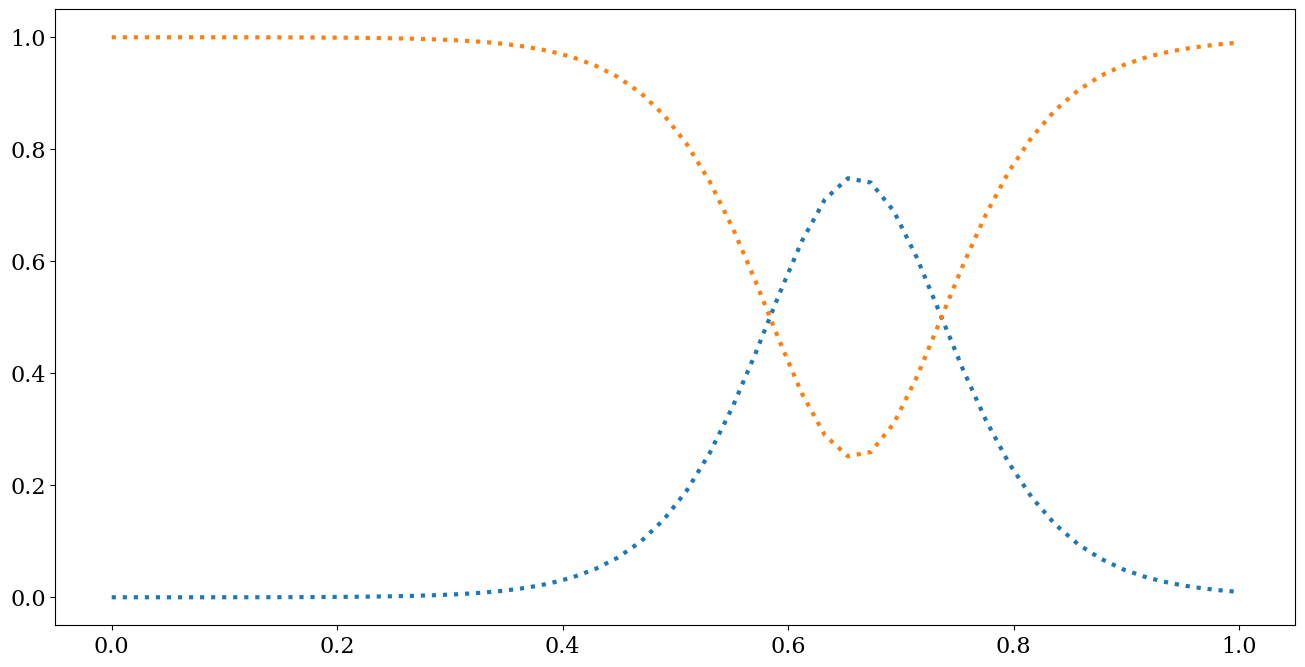

In [5]:
"""
Set up to evaluate classical solution

Working on 4 neutrino case, 2 neutrinos and 2 antineutrinos.
"""

L          = 1
t_steps    = 50
theta      = np.pi/2 - 0.01
dmsq       = 1.0
Delta      = dmsq / (2*0.1) * np.array([1.,1.,-1.,-1.])  # minus sign for the kinetic terms for antineutrinos
b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
J          = 5 * np.ones((4, 4))
nu_mask    = [True,True,False,False]
nubar_mask = [False,False,True,True]

# mean-field solution
L_table = np.linspace(0, L, t_steps)
sol     = P_osc_RS(L_table, theta, np.array([Delta[0], -Delta[0]]), 0., 2*abs(J[::2,::2])) # factor 2 because we compare to a system with 2 nu + 2 nubar
P_table = np.reshape(sol.y, (2,3,len(L_table)))

for k in range(len(P_table)):
    plt.plot(L_table, 0.5*(1-P_table[k,2,:]), ls=':', lw=3)

cl.add("classical_nu", np.squeeze(0.5*(1-P_table[0,2,:])))
cl.add("classical_nubar", np.squeeze(0.5*(1-P_table[1,2,:])))

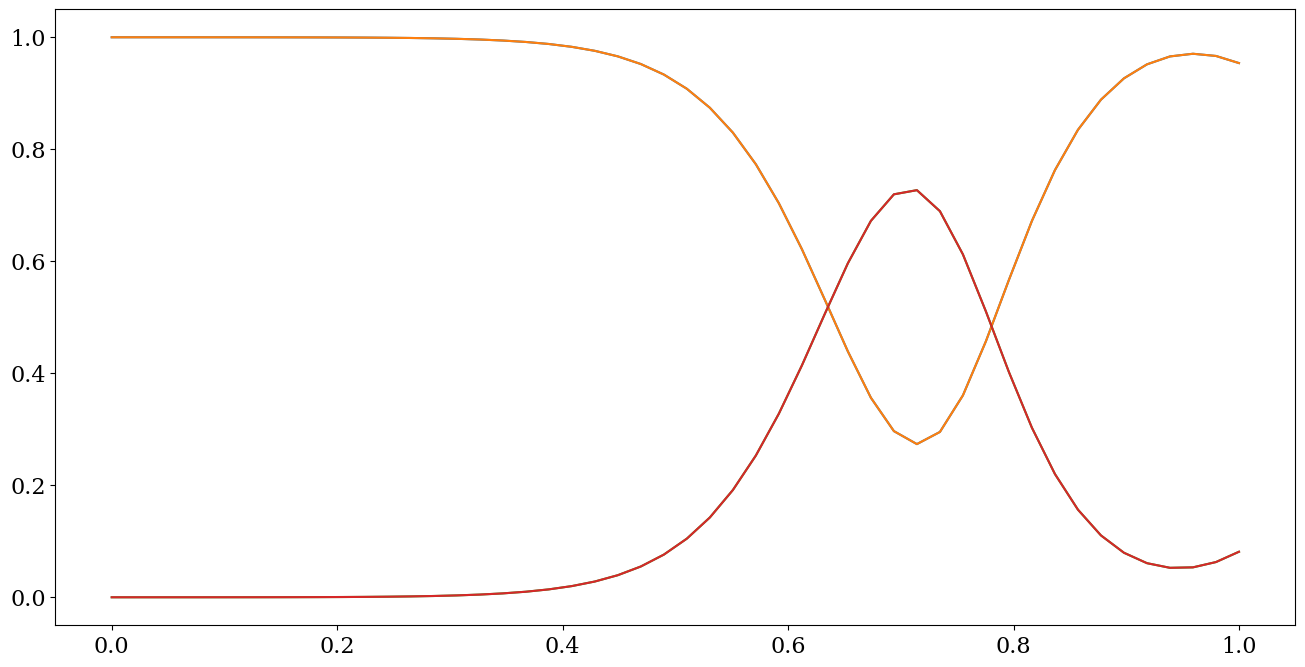

In [6]:
"""
Evaluating using quantum simulation with strict single body term from mean field theory
No entangling.
"""

L          = 1
t_steps    = 50
theta      = np.pi/2 - 0.01
dmsq       = 1.0
Delta      = dmsq / (2*0.1) * np.array([1.,1.,-1.,-1.])  # minus sign for the kinetic terms for antineutrinos
b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
J          = 5 * np.ones((4, 4))
nu_mask    = [True,True,False,False]
nubar_mask = [False,False,True,True]

L_table_quant = np.linspace(0, L, t_steps)
dt_table       = np.diff(L_table_quant)

# loop over time steps
n_qubits = 4
qc = qk.QuantumCircuit(n_qubits)
for j in np.nonzero(nubar_mask): # we use Duan and Fuller's convention here where \nu_e = |0> and \bar\nu_e = |1>
    qc.x(j)
for i in range(len(dt_table)):
    dt = dt_table[i]

    # artificially remove entanglement by resetting each qubit to a non-entangled state
    qc_no_save = qc.remove_final_measurements(inplace=False)
    qc_no_save.data = [inst for inst in qc.data if inst.operation.name != 'save_density_matrix']
    sv = qk.quantum_info.Statevector(qc_no_save)
    rho = [ np.array(qk.quantum_info.partial_trace(sv, [j for j in range(n_qubits) if j != k])) for k in range(n_qubits) ]
    p   = [ np.real(np.array([ np.trace(sigma_1@rho[k]), np.trace(sigma_2@rho[k]), np.trace(sigma_3@rho[k]) ])) for k in range(n_qubits) ]
    
    # reset qubits to a non-entangled state to emulate the mean-field picture
    qc.reset(range(n_qubits))
    for j in range(n_qubits):
        qc.ry(np.arccos(p[j][2]), j)
        qc.rz(np.arctan2(p[j][1], p[j][0]), j)

    qc.save_density_matrix(label=str(i+1))

    # strict mean-field: single-qubit evolution only, no entangling gates
    for j in range(4):
        qc.rx(-dt*Delta[j]*b[0], j)
        qc.rz(-dt*Delta[j]*b[2], j)
    for j in range(4):
        for k in range(4):
            qc.rx(-dt*J[j,k] * p[k][0], j)
            qc.ry(-dt*J[j,k] * p[k][1], j)
            qc.rz(-dt*J[j,k] * p[k][2], j)

# save final state
qc.save_density_matrix(label=str(i+2))

# run simulation    
sim = aer.AerSimulator(method="statevector", precision="double", zero_threshold=1e-14, validation_threshold=1e-12)
result = sim.run(qc).result()

# extract and plot results
n_qubits = qc.num_qubits
rho_reduced = [ { k : np.array(qk.quantum_info.partial_trace(result.data()[k], [q for q in range(n_qubits) if q != j])) for k in result.data().keys() } for j in range(n_qubits) ]
pp = np.array([ [[float(k), rho_reduced[j][k][0,0]] for k in rho_reduced[j].keys() ] for j in range(n_qubits) ])
pp = np.abs(np.take_along_axis(pp, pp[:,:,0].argsort(axis=1)[:,:,None], axis=1))
for j in range(n_qubits):
    plt.plot(L_table_quant, pp[j,:,1])

for j in range(n_qubits):
    cl.add(f"quantum_single_{j}", pp[j,:,1])

100%|██████████| 49/49 [00:02<00:00, 17.63it/s]


Finished time steps, saving final state...
Running quantum simulation...
Quantum simulation finished.
Extracting results...


100%|██████████| 4/4 [00:00<00:00, 41630.81it/s]


Results computed. Plotting...


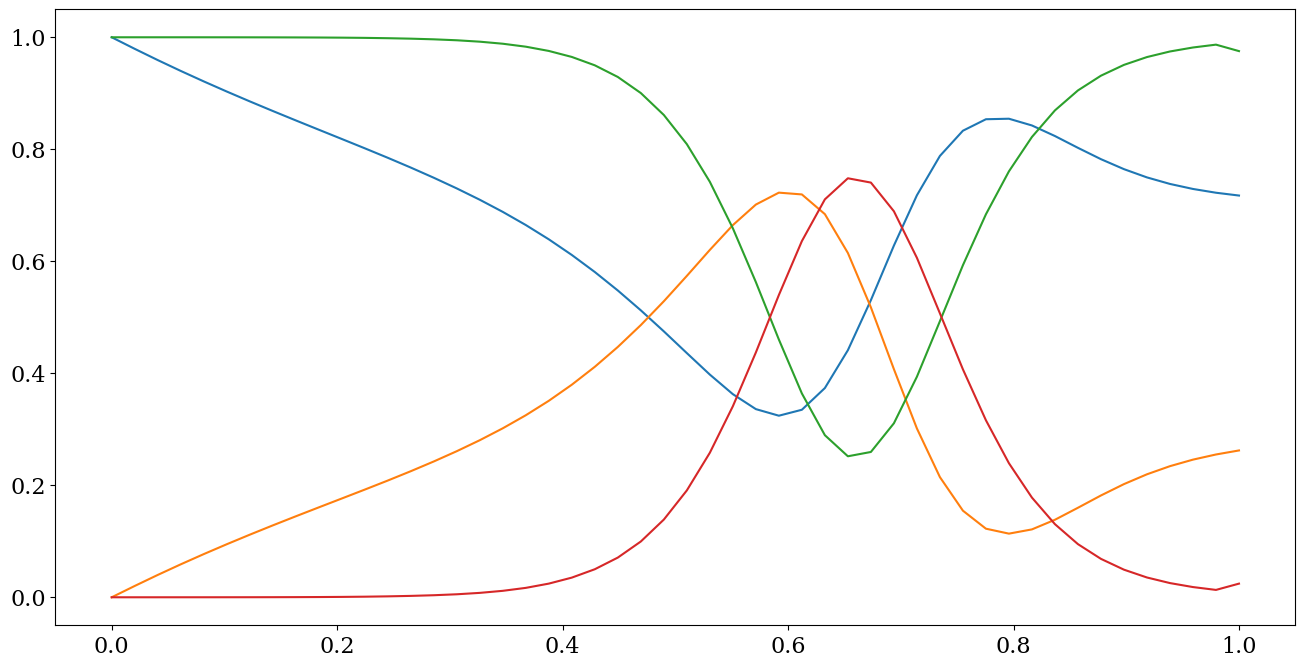

In [ ]:
"""
Try to replicate the single body mean field result by using qubits set to mean field solution.

There are two body entanglements.
"""

L          = 1
t_steps    = 50
theta      = np.pi/2 - 0.01
dmsq       = 1.0
Delta      = dmsq / (2*0.1) * np.array([1.,1.,-1.,-1.])  # minus sign for the kinetic terms for antineutrinos
b          = np.array([np.sin(2*theta), 0, -np.cos(2*theta)]) # the structure of the vacuum Hamiltonian in the Pauli basis
J          = 5 * np.ones((4, 4))
nu_mask    = [True,True,False,False]
nubar_mask = [False,False,True,True]

L_table_quant = np.linspace(0, L, t_steps)
dt_table       = np.diff(L_table_quant)

# loop over time steps

n_qubits = 10
qc = qk.QuantumCircuit(n_qubits)

#-------------------
# Initialization

# 0 is our test nu_e, 1 is our test nubar_e
# same as the single body quantum case above
# we use Duan and Fuller's convention here where \nu_e = |0> and \bar\nu_e = |1>

qc.x(1) # 0 is our test nu_e, 1 is our test nubar_e

# -------------------
# loop over time steps

for i in tqdm(range(len(dt_table))):
    dt = dt_table[i]

    # artificially remove entanglement by resetting each qubit to a non-entangled state
    qc_no_save = qc.remove_final_measurements(inplace=False)
    qc_no_save.data = [inst for inst in qc.data if inst.operation.name != 'save_density_matrix']
    sv = qk.quantum_info.Statevector(qc_no_save)
    rho = [ np.array(qk.quantum_info.partial_trace(sv, [j for j in range(n_qubits) if j != k])) for k in range(n_qubits) ]
    p   = [ np.real(np.array([ np.trace(sigma_1@rho[k]), np.trace(sigma_2@rho[k]), np.trace(sigma_3@rho[k]) ])) for k in range(n_qubits) ]

    # The P_table containes the mean field solution
    # In this notebook, since we calculated it in the first cell, we can use it directly
    # Here we set qubit 2, 3, 4, 5 to the mean field solution of nu_e
    p[2] = np.array([P_table[0,0,i], P_table[0,1,i], P_table[0,2,i]])
    p[3] = p[2]
    p[4] = p[2]
    p[5] = p[2]

    # Then set qubit 6, 7, 8, 9 to the mean field solution of nubar_e
    p[6] = np.array([P_table[1,0,i], P_table[1,1,i], P_table[1,2,i]])
    p[7] = p[6]
    p[8] = p[6]
    p[9] = p[6]

    # reset qubits to a non-entangled state to emulate the mean-field picture
    qc.reset(range(n_qubits))
    for j in range(n_qubits):
        qc.ry(np.arccos(p[j][2]), j)
        qc.rz(np.arctan2(p[j][1], p[j][0]), j)

    qc.save_density_matrix(label=str(i+1))

    # Single body evolution, here only to our two test neutrinos 0 and 1

    qc.rx(-dt*Delta[0]*b[0], 0)
    qc.rz(-dt*Delta[0]*b[2], 0)

    qc.rx(dt*Delta[0]*b[0], 1)
    qc.rz(dt*Delta[0]*b[2], 1)

    # Single body evolution for the mean fields, seperated in case we comment this part out

    # I have tried removing single body evolution for the mean fields, but result is not very different

    for j in range(2, 6):  # nu_e mean fields
        qc.rx(-dt*Delta[0]*b[0], j)
        qc.rz(-dt*Delta[0]*b[2], j)
    for j in range(6, 10): # nubar_e mean fields
        qc.rx(dt*Delta[0]*b[0], j)
        qc.rz(dt*Delta[0]*b[2], j)

    # -------------------------
    # Two body evolution, between test neutrino 0 and 1 and the mean fields
    # We interact between neutrino 0 and 2 nu_e + 2 nubar_e
    # The interact between neutrino 1 and 2 nu_e + 2 nubar_e

    # In this convention, J is uniformly the same value

    Jval = J[0, 0]

    # interact neutrino 0 with neutrinos 2, 3, 6, 7
    for j in [2, 3, 6, 7]:
        # qc.rxx(-dt*Jval, 0, j)
        # qc.ryy(-dt*Jval, 0, j)
        # qc.rzz(-dt*Jval, 0, j)
        qc.unitary(U_self_int(-dt*Jval), [0, j])
    # interact neutrino 1 with neutrinos 4, 5, 8, 9
    for j in [4, 5, 8, 9]:
        # qc.rxx(-dt*Jval, 1, j)
        # qc.ryy(-dt*Jval, 1, j)
        # qc.rzz(-dt*Jval, 1, j)
        qc.unitary(U_self_int(-dt*Jval), [1, j])

# end for (time steps)
print("Finished time steps, saving final state...")

# save final state
qc.save_density_matrix(label=str(i+2))

print("Running quantum simulation...")

# run simulation    
sim = aer.AerSimulator(method="statevector", precision="double", zero_threshold=1e-14, validation_threshold=1e-12)
result = sim.run(qc).result()

print("Quantum simulation finished.")
print("Extracting results...")
# extract and plot results
n_qubits = qc.num_qubits
# we same results for the two test neutrinos, and two mean fields for reference
rho_reduced = [ { k : np.array(qk.quantum_info.partial_trace(result.data()[k], [q for q in range(n_qubits) if q != j])) for k in result.data().keys() } for j in tqdm([0, 1, 2, 9])]
pp = np.array([ [[float(k), rho_reduced[j][k][0,0]] for k in rho_reduced[j].keys() ] for j in tqdm(range(4)) ])
pp = np.abs(np.take_along_axis(pp, pp[:,:,0].argsort(axis=1)[:,:,None], axis=1))

print("Results computed. Plotting...")

for j in range(4):
    plt.plot(L_table_quant, pp[j,:,1])

for j in [0, 1]:
    cl.add(f"quantum_ent_{j}", pp[j,:,1])

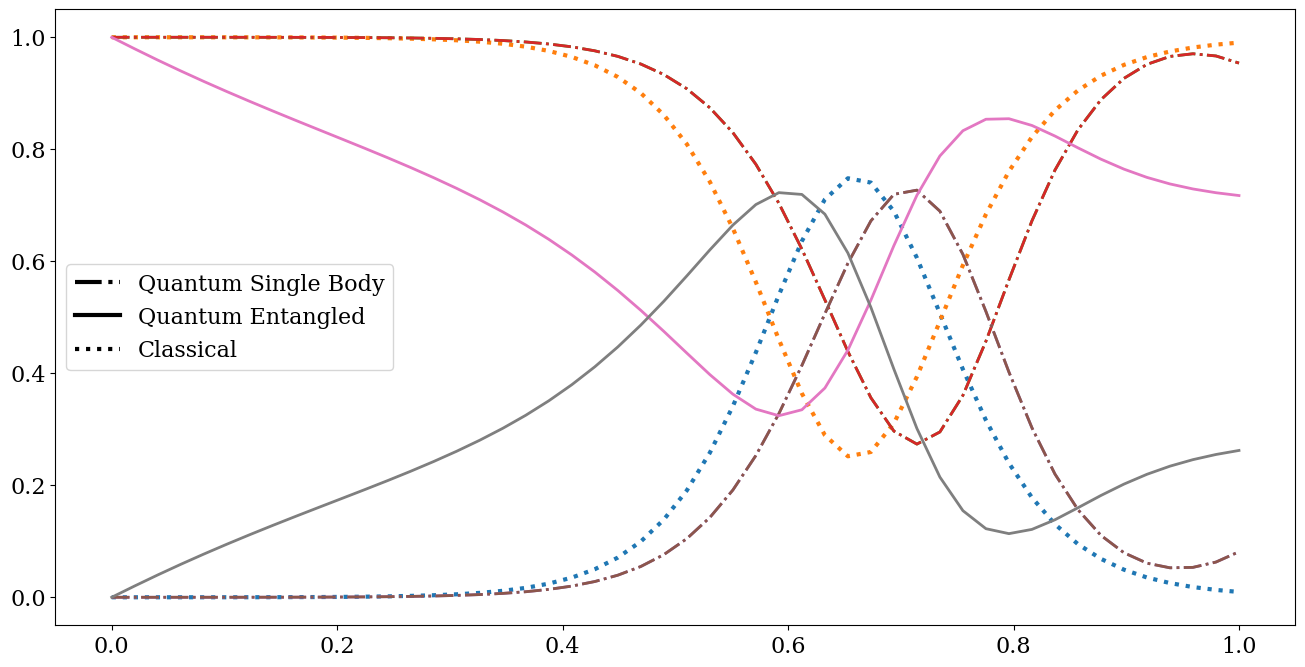

In [8]:
# Now plot everything all together
plt.clf()

# mean field
plt.plot(L_table, cl.get("classical_nu")[0], ls=':', lw=3)
plt.plot(L_table, cl.get("classical_nubar")[0], ls=':', lw=3)

# strict single body
for j in range(4):
    plt.plot(L_table_quant, cl.get(f"quantum_single_{j}")[0], ls='dashdot', lw=2)

# entangled two body
for j in [0, 1]:
    plt.plot(L_table_quant, cl.get(f"quantum_ent_{j}")[0], ls='-', lw=2)

from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='black', lw=3, linestyle='dashdot'),
    Line2D([0], [0], color='black', lw=3, linestyle='-'),
    Line2D([0], [0], color='black', lw=3, linestyle=':')
]

# Add the legend
plt.legend(custom_lines, ['Quantum Single Body', 'Quantum Entangled', 'Classical'])

